# Plot a bar chart of literatures
- This script is used to plot a bar chart of WRF literatures by year.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df_literature = pd.read_excel('WRF_high_urban_albedo_2011-2025.xlsx', skiprows=1)
years = (
    df_literature['Publication Year']
    .astype(str)
    .str.extract(r'(\d{4})')[0]
    .astype(int)
)

In [41]:
year_counts = years.value_counts().sort_index()
year_counts

0
2011     1
2012     1
2013     3
2014     4
2015     2
2016     8
2017     6
2018    11
2019     6
2020    13
2021     9
2022     7
2023    12
2024     9
2025    12
Name: count, dtype: int64

In [43]:
year_counts.sum()

np.int64(104)

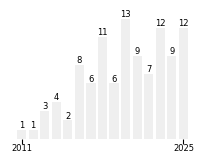

In [42]:
fig, ax = plt.subplots(figsize=(2, 1.45))
labelcolor = '#6b6b6b'
fontsize = 6
ticklabel_pad = 0.2
bars = ax.bar(year_counts.index, year_counts.values, color=labelcolor, alpha=0.1)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='y', labelleft=False, left=False)  
ax.tick_params(axis='x', labelbottom=True, labelsize=fontsize, pad=ticklabel_pad)
ax.set_xlim(2010, 2026)
ax.set_xticks([2011, 2025])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=fontsize
    )
plt.subplots_adjust(left=0.05, right=0.975, bottom=0.1, top=0.97)    
fig.savefig('literature_counts.png', dpi=300, transparent=True)    